In [ ]:
# Notebook configuration: set to True to save generated images (default: False)
import os
SAVE_IMAGES = False

def savefig_cond(fname, **kwargs):
    if SAVE_IMAGES:
        os.makedirs(os.path.dirname(fname), exist_ok=True)
        plt.savefig(fname, **kwargs)


### **DC Motor Modeling with Nonlinear Load (Fan)**


# Step 1: Mathematical Modeling of the System

Following standard textbooks, the dynamics of an independently excited DC motor can be modeled with two coupled loops: the electrical (armature) and the mechanical (rotor + load).

1.1 Electrical loop (armature dynamics)

Applying Kirchhoff's Voltage Law:

$$v_a(t) = R_a i_a(t) + L_a \frac{di_a(t)}{dt} + e_a(t)$$

The back-emf $e_a$ is proportional to mechanical angular speed $\omega_m$:

$$e_a(t) = K_m \omega_m(t)$$

Isolating the derivative of current:

$$\frac{di_a(t)}{dt} = \frac{1}{L_a} v_a(t) - \frac{R_a}{L_a} i_a(t) - \frac{K_m}{L_a} \omega_m(t) \quad (Eq. 1)$$

1.2 Mechanical loop (shaft + load)

Electromagnetic torque is proportional to armature current:

$$T_e(t) = K_m i_a(t)$$

Newton's second law for rotation:

$$J \frac{d\omega_m(t)}{dt} = T_e(t) - B_m \omega_m(t) - T_L(t)$$

Nonlinear aerodynamic load (fan): torque grows with the square of speed:

$$T_L(t) = k \omega_m^2(t)$$

Substituting $T_e$ and $T_L$ and isolating the speed derivative:

$$\frac{d\omega_m(t)}{dt} = \frac{K_m}{J} i_a(t) - \frac{B_m}{J} \omega_m(t) - \frac{k}{J} \omega_m^2(t) \quad (Eq. 2)$$


# Step 2: Model Linearization

The presence of the $\omega_m^2(t)$ term in (Eq. 2) makes the system nonlinear. To apply classical control techniques and obtain a transfer function, we linearize the model around an equilibrium operating point (where derivatives are zero).

Let the nominal operating point be:

- Nominal voltage: $v_{a0}$
- Nominal current: $i_{a0}$
- Nominal speed: $\omega_0$

At equilibrium, $\frac{d\omega_m(t)}{dt} = 0$. Therefore:

$$0 = K_m i_{a0} - B_m \omega_0 - k \omega_0^2 \implies K_m i_{a0} = B_m \omega_0 + k \omega_0^2$$

## 2.1 Taylor Series Expansion

Define deviation variables (small perturbations around the operating point):

$$\Delta\omega(t) = \omega_m(t) - \omega_0$$

$$\Delta i_a(t) = i_a(t) - i_{a0}$$

$$\Delta v_a(t) = v_a(t) - v_{a0}$$

Linearize the nonlinear mechanical term $f(\omega_m) = B_m \omega_m + k \omega_m^2$ using the first-order Taylor approximation around $\omega_0$.

The derivative is:

$$\frac{\partial f}{\partial \omega_m} = B_m + 2k\omega_m$$

Evaluated at the operating point $\omega_0$, the equivalent viscous friction is:

$$B_{eq} = B_m + 2k\omega_0$$

## 2.2 Linearized State-Space Equations

Substituting deviation variables and the linearized drag term yields the linear state-space model:

$$\frac{d(\Delta i_a)}{dt} = - \frac{R_a}{L_a} \Delta i_a(t) - \frac{K_m}{L_a} \Delta\omega(t) + \frac{1}{L_a} \Delta v_a(t)$$

$$\frac{d(\Delta\omega)}{dt} = \frac{K_m}{J} \Delta i_a(t) - \frac{B_{eq}}{J} \Delta\omega(t)$$

Here the nonlinear aerodynamic drag $k\omega_m^2$ is approximated as an increased linear viscous friction $2k\omega_0 \cdot \Delta\omega$, valid for small deviations around $\omega_0$.


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct

# Numerical parameters for the DC motor
params = {
    'Ra': 2.0,      # Armature resistance (Ohms)
    'La': 0.5,      # Armature inductance (H)
    'Km': 0.1,      # Torque/back-emf constant (N.m/A or V.s/rad)
    'J': 0.02,      # Inertia (kg.m^2)
    'Bm': 0.01,     # Viscous friction (N.m.s/rad)
    'k': 0.001,     # Aerodynamic constant (N.m.s^2/rad^2)
    'Va0': 24.0     # Nominal voltage (V)
}

# --- Operating point calculation ---
a = params['k']
b = params['Bm'] + (params['Km']**2) / params['Ra']
c = - (params['Km'] * params['Va0']) / params['Ra']

# Solve quadratic: a*w0^2 + b*w0 + c = 0
roots = np.roots([a, b, c])
w0 = [r for r in roots if r > 0][0]  # take positive root
ia0 = (params['Va0'] - params['Km']*w0) / params['Ra']

print("--- OPERATING POINT (STEADY STATE) ---")
print(f"Nominal speed (w0): {w0:.2f} rad/s")
print(f"Nominal current (ia0): {ia0:.2f} A")

# --- Linearization ---
Beq = params['Bm'] + 2 * params['k'] * w0
print(f"Linearized equivalent friction (Beq): {Beq:.4f} N.m.s/rad")

# State-space matrices (linearized around operating point)
A = np.array([
    [-params['Ra']/params['La'], -params['Km']/params['La']],
    [params['Km']/params['J'],   -Beq/params['J']]
])
B = np.array([[1/params['La']], [0]])
C = np.array([[0, 1]])  # output is speed (w)
D = np.array([[0]])

# Create linear state-space system and transfer function
dc_motor_sys = ct.ss(A, B, C, D)
G_s = ct.ss2tf(dc_motor_sys)
print(f"\nPlant transfer function G(s): \n{G_s}")


--- OPERATING POINT (STEADY STATE) ---
Nominal speed (w0): 27.94 rad/s
Nominal current (ia0): 10.60 A
Linearized equivalent friction (Beq): 0.0659 N.m.s/rad

Plant transfer function G(s): 
<TransferFunction>: sys[56]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    -8.882e-16 s + 10
  ---------------------
  s^2 + 7.294 s + 14.18


# Step 3: Time Response Analysis (Step)

With the linearized plant transfer function $G(s)$, we can evaluate transient behavior. This model uses deviation variables: a unit step $\Delta v_a(t)=1V$ corresponds to $\Delta\omega(t)$ relative to operating point $\omega_0$.

The following cell simulates a unit step (+1V) and extracts classical performance metrics (rise time, settling time, overshoot).

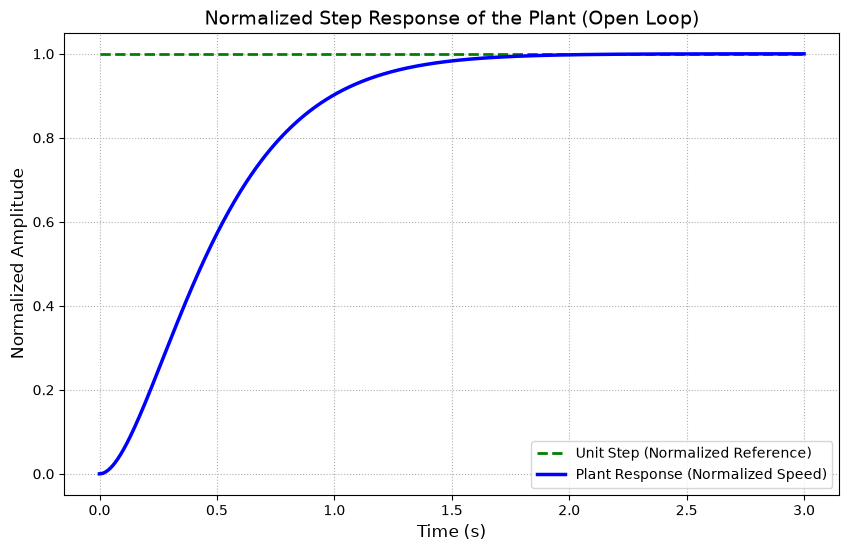

--- OPEN-LOOP PERFORMANCE METRICS ---
Rise Time (tr): 0.842 s
Settling Time (ts): 1.473 s
Overshoot (Mp): 0.00 %


In [ ]:
# --- NORMALIZED STEP RESPONSE SIMULATION ---
# (images saved only when SAVE_IMAGES=True)
import os

t = np.linspace(0, 3, 1000)

# Apply unit step (+1V) to the linearized model
T_step, delta_w = ct.step_response(dc_motor_sys, T=t)

# DC gain (steady-state value for step input)
dc_gain = ct.dcgain(dc_motor_sys)

# Normalize output signal
speed_norm = delta_w / dc_gain

# Ideal unit step (Normalized reference)
ideal_step = np.ones_like(t)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(t, ideal_step, 'g--', linewidth=2, label='Unit Step (Normalized Reference)')
plt.plot(T_step, speed_norm, 'b-', linewidth=2.5, label='Plant Response (Normalized Speed)')

plt.title('Normalized Step Response of the Plant (Open Loop)', fontsize=14)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Normalized Amplitude', fontsize=12)
plt.grid(True, linestyle=':')
plt.legend(loc='lower right')
savefig_cond('images/step_response.png', dpi=150)
plt.show()

# --- PERFORMANCE METRICS ---
info = ct.step_info(dc_motor_sys)
print("--- OPEN-LOOP PERFORMANCE METRICS ---")
print(f"Rise Time (tr): {info['RiseTime']:.3f} s")
print(f"Settling Time (ts): {info['SettlingTime']:.3f} s")
print(f"Overshoot (Mp): {info['Overshoot']:.2f} %")


# Step 4: Response to Ramp and Parabolic Inputs

To evaluate the plant behavior against continuously varying reference signals, we apply ramp inputs ($r(t)=t$) and parabolic inputs ($r(t)=t^2/2$).

Physically, in a DC motor context:

- Ramp input: represents a constant acceleration request (voltage increases linearly).
- Parabolic input: represents a steadily increasing acceleration (jerk).

Because the plant has inertia ($J$) and inductance ($L_a$), it cannot change speed instantaneously, producing tracking error. The code cell below uses `forced_response` to inject these normalized signals and plot the results.

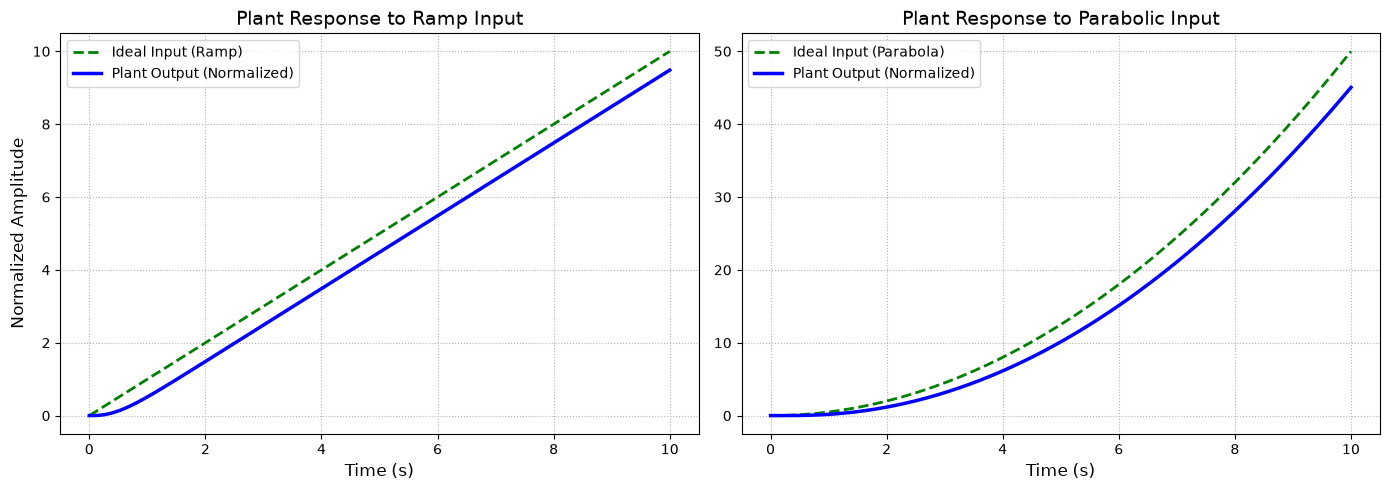

In [ ]:
# --- SIMULATION FOR RAMP AND PARABOLA INPUTS ---
# (images saved only when SAVE_IMAGES=True)

t_sim = np.linspace(0, 10, 1000)

# Input vectors
u_ramp = t_sim
u_parabola = 0.5 * (t_sim**2)

# Response to ramp
_, y_ramp = ct.forced_response(dc_motor_sys, T=t_sim, U=u_ramp)
y_ramp_norm = y_ramp / dc_gain  # normalize by DC gain

# Response to parabola
_, y_parabola = ct.forced_response(dc_motor_sys, T=t_sim, U=u_parabola)
y_parabola_norm = y_parabola / dc_gain

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Ramp
ax1.plot(t_sim, u_ramp, 'g--', linewidth=2, label='Ideal Input (Ramp)')
ax1.plot(t_sim, y_ramp_norm, 'b-', linewidth=2.5, label='Plant Output (Normalized)')
ax1.set_title('Plant Response to Ramp Input', fontsize=14)
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Normalized Amplitude', fontsize=12)
ax1.grid(True, linestyle=':')
ax1.legend()

# Parabola
ax2.plot(t_sim, u_parabola, 'g--', linewidth=2, label='Ideal Input (Parabola)')
ax2.plot(t_sim, y_parabola_norm, 'b-', linewidth=2.5, label='Plant Output (Normalized)')
ax2.set_title('Plant Response to Parabolic Input', fontsize=14)
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.grid(True, linestyle=':')
ax2.legend()

plt.tight_layout()
savefig_cond('images/ramp_parabola_responses.png', dpi=150)
plt.show()


# Step 5: Determination and Discussion of Performance Metrics (Second-Order Analysis)

To classify the damping of our system, examine the roots (poles) of the characteristic equation of $G(s)$. These provide the damping factor ($\zeta$) and the undamped natural frequency ($\omega_n$).

The standard second-order characteristic equation is:

$$s^2 + 2\zeta\omega_n s + \omega_n^2 = 0$$

Classification rules:

- $\zeta > 1$: Overdamped — two real distinct poles; slow response without oscillation.
- $\zeta = 1$: Critically damped — fastest response without oscillation.
- $0 < \zeta < 1$: Underdamped — complex conjugate poles; oscillatory response (overshoot).

The code cell below extracts these properties from our linearized model.

In [4]:
# --- EXTRACT ZETA (damping), WN AND POLES ---
# damp() returns natural frequency (wn), damping (zeta) and poles
wn, zeta, poles = ct.damp(dc_motor_sys, doprint=False)

print("--- SECOND-ORDER ANALYSIS OF THE PLANT ---")
print(f"System poles: {poles[0]:.4f} and {poles[1]:.4f}")
print(f"Natural frequency (wn): {wn[0]:.4f} rad/s")
print(f"Damping factor (zeta): {zeta[0]:.4f}")

if zeta[0] > 1:
    print("Theoretical classification: Overdamped system.")
elif zeta[0] == 1:
    print("Theoretical classification: Critically damped system.")
else:
    print("Theoretical classification: Underdamped system.")


--- SECOND-ORDER ANALYSIS OF THE PLANT ---
System poles: -3.6472+0.9357j and -3.6472-0.9357j
Natural frequency (wn): 3.7653 rad/s
Damping factor (zeta): 0.9686
Theoretical classification: Underdamped system.


The analytical calculation returns a damping factor $\zeta \approx 0.968$. Although theoretically underdamped, the overshoot is numerically negligible, so the plant behaves practically as critically damped. This is worth noting in the report: the theoretical classification and the practical response can differ when damping is very close to 1.

# Step 6: PID Controller Design via Pole Placement

The closed-loop design must satisfy these requirements:

- Rise time ($t_r$) $\le 0.5$ s
- Settling time ($t_s$) $\le 1.0$ s (2% criterion)
- Overshoot ($M_p$) $\le 10.0\%$

Using standard control relations (Franklin):

1. Overshoot limit $M_p$:
$$ M_p = e^{-\pi \zeta / \sqrt{1-\zeta^2}} \le 0.10 \implies \zeta \ge 0.591 $$
We choose $\zeta = 0.8$ for margin.

2. Rise time estimate:
$$ t_r \approx \frac{1.8}{\omega_n} \le 0.5 \implies \omega_n \ge 3.6 \text{ rad/s} $$
We adopt $\omega_n = 10$ rad/s for responsiveness without aggressive peaks.

3. Settling time validation:
$$ t_s \approx \frac{4}{\zeta \omega_n} = \frac{4}{0.8 \times 10} = 0.50 \text{ s} $$

Desired dominant poles:
$$ s_{1,2} = -\zeta\omega_n \pm j\omega_n\sqrt{1-\zeta^2} = -8 \pm j6 $$

Because the PID introduces an integrator (pole at the origin), the closed-loop becomes third-order; choose a third pole $s_3 = -80$ (10× further left) to keep it non-dominant.

Below we compute $K_p$, $K_i$, $K_d$ via polynomial matching (Diophantine) and simulate the closed-loop response.

--- PID GAINS (Pole Placement) ---
Kp = 136.5823
Ki = 800.0000
Kd = 8.8706


c:\Users\Pichau\Desktop\MotorCC\.venv\Lib\site-packages\scipy\signal\_lti_conversion.py:77: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  num, den = normalize(num, den)   # Strips zeros, checks arrays


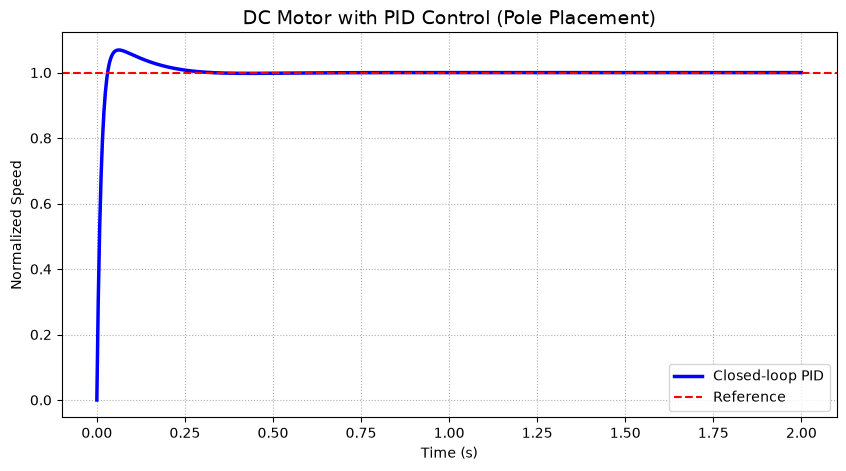

--- CLOSED-LOOP PERFORMANCE ---
Rise Time (tr): 0.021 s   [Target: <= 0.5 s]
Settling Time (ts): 0.191 s   [Target: <= 1.0 s]
Overshoot (Mp): 6.90 %       [Target: <= 10.0 %]
PROJECT STATUS: Approved ✅


In [ ]:
import math
from src.motor_simulation import design_pid_by_pole_placement

# --- 1. Desired poles ---
zeta_d = 0.8
wn_d = 10.0
s1 = complex(-zeta_d * wn_d, wn_d * math.sqrt(1 - zeta_d**2))
s2 = complex(-zeta_d * wn_d, -wn_d * math.sqrt(1 - zeta_d**2))
s3 = complex(-80, 0)

desired_poles = [s1, s2, s3]

# Compute polynomial coefficients
poly_desired = np.poly(desired_poles)

# --- 2. Extract plant parameters ---
num_G = G_s.num[0][0]
den_G = G_s.den[0][0]

c0 = num_G[-1]
a1 = den_G[1]
a2 = den_G[2]

# --- 3. Compute PID gains via Diophantine equality ---
Kd = (poly_desired[1] - a1) / c0
Kp = (poly_desired[2] - a2) / c0
Ki = poly_desired[3] / c0

print("--- PID GAINS (Pole Placement) ---")
print(f"Kp = {Kp:.4f}")
print(f"Ki = {Ki:.4f}")
print(f"Kd = {Kd:.4f}")

# --- 4. Simulate closed-loop with PID ---
num_pid = [Kd, Kp, Ki]
den_pid = [1, 0]
C_pid = ct.tf(num_pid, den_pid)

sys_closed = ct.feedback(C_pid * G_s, 1)

# Step response
t_pid = np.linspace(0, 2.0, 1000)
T_pid, y_pid = ct.step_response(sys_closed, T=t_pid)

plt.figure(figsize=(10, 5))
plt.plot(T_pid, y_pid, 'b-', linewidth=2.5, label='Closed-loop PID')
plt.axhline(1, color='r', linestyle='--', label='Reference')
plt.title('DC Motor with PID Control (Pole Placement)', fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('Normalized Speed')
plt.grid(True, linestyle=':')
plt.legend()
savefig_cond('images/pid_response.png', dpi=150)
plt.show()

# --- 5. Performance metrics ---
info_pid = ct.step_info(sys_closed)
print("--- CLOSED-LOOP PERFORMANCE ---")
print(f"Rise Time (tr): {info_pid['RiseTime']:.3f} s   [Target: <= 0.5 s]")
print(f"Settling Time (ts): {info_pid['SettlingTime']:.3f} s   [Target: <= 1.0 s]")
print(f"Overshoot (Mp): {info_pid['Overshoot']:.2f} %       [Target: <= 10.0 %]")

approved = (info_pid['RiseTime'] <= 0.5) and (info_pid['SettlingTime'] <= 1.0) and (info_pid['Overshoot'] <= 10.0)
print(f"PROJECT STATUS: {'Approved ✅' if approved else 'Rejected ❌'}")


# Step 7: Stability Assessment and Critical Proportional Gain (Kp_crit)

Stability can be assessed via Routh-Hurwitz or Root Locus. The proportional critical gain is the gain at which closed-loop poles cross into instability. The following code computes gain margin and plots the root locus for visualization.

c:\Users\Pichau\Desktop\MotorCC\.venv\Lib\site-packages\scipy\signal\_filter_design.py:1234: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)
c:\Users\Pichau\Desktop\MotorCC\.venv\Lib\site-packages\control\rlocus.py:202: FutureWarning: root_locus() return value of roots, gains is deprecated; use root_locus_map()
  warnings.warn(
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


--- STABILITY ANALYSIS AND CRITICAL GAIN ---
Proportional Critical Gain (Kp_crit / Gain Margin): 8212721180674761.0
Numerical interpretation: margin is effectively infinite; the open-loop plant is unconditionally stable.


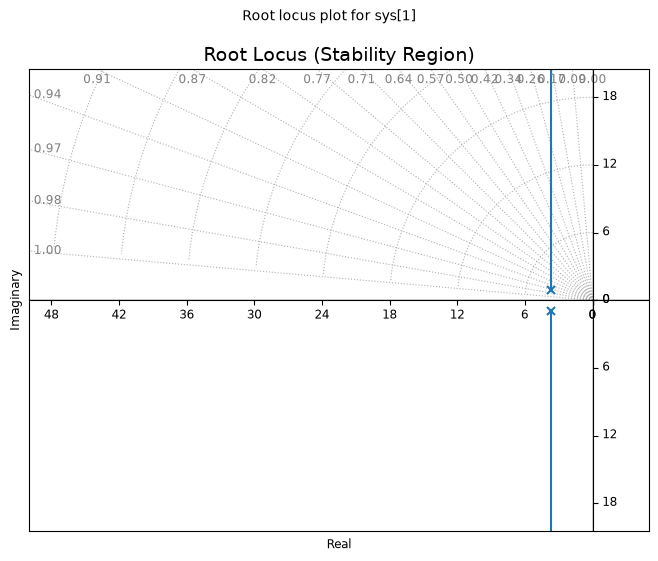


STATUS: The plant remains stable for P gains > 0 in the tested range.


In [8]:
# --- DETERMINATION OF THE CRITICAL GAIN (Kp_crit) ---

# Compute gain margin using margin()
gm, pm, wg, wp = ct.margin(G_s)

print("--- STABILITY ANALYSIS AND CRITICAL GAIN ---")
print(f"Proportional Critical Gain (Kp_crit / Gain Margin): {gm}")

if gm == float('inf') or gm > 1e10:
    print("Numerical interpretation: margin is effectively infinite; the open-loop plant is unconditionally stable.")
else:
    print(f"The system has a finite stability limit at Kp = {gm:.4f}")

# --- ROOT LOCUS FOR VISUALIZATION ---
plt.figure(figsize=(8, 6))

# Use gains range for plotting
gains = np.linspace(0, 500, 1000)

# Prefer transfer-function input for rlocus and pass gains explicitly; include fallback
try:
    rlist, klist = ct.rlocus(G_s, gains=gains, plot=True, grid=True)
except TypeError:
    rlist, klist = ct.rlocus(G_s, gains=list(gains), plot=True, grid=True)

plt.xlim([-50, 5])
plt.ylim([-20, 20])
plt.title('Root Locus (Stability Region)', fontsize=14)
plt.grid(True)
plt.show()

print("\nSTATUS: The plant remains stable for P gains > 0 in the tested range.")


# Step 8: Performance Comparison between Controllers (P, PI, PD, PID)

This step compares the designed PID with simplified variants (P, PI, PD). We evaluate steady-state error and transient performance and summarize results in a table.

c:\Users\Pichau\Desktop\MotorCC\.venv\Lib\site-packages\scipy\signal\_lti_conversion.py:77: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  num, den = normalize(num, den)   # Strips zeros, checks arrays
c:\Users\Pichau\Desktop\MotorCC\.venv\Lib\site-packages\scipy\signal\_lti_conversion.py:77: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  num, den = normalize(num, den)   # Strips zeros, checks arrays


Controller   tr (s)   ts (s)    Mp (%)   Status
         P 0.033821 1.041699 72.910737 REJECTED
        PI 0.027130 5.351333 92.666963 REJECTED
        PD 0.019357 0.126703  5.425057 APPROVED
       PID 0.020682 0.191308  6.897722 APPROVED


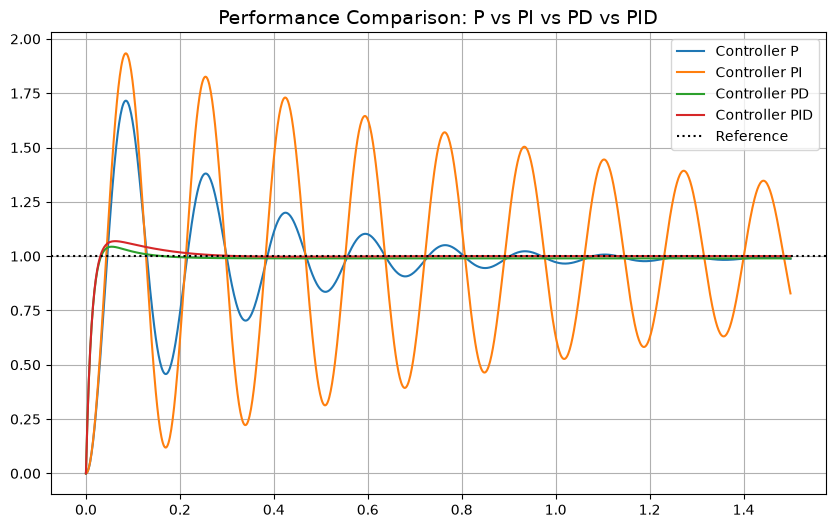

In [ ]:
import pandas as pd

# Define controllers
C_P = ct.tf([Kp], [1])
C_PI = ct.tf([Kp, Ki], [1, 0])
C_PD = ct.tf([Kd, Kp], [1])
C_PID = ct.tf([Kd, Kp, Ki], [1, 0])

systems = {
    "P": ct.feedback(C_P * G_s, 1),
    "PI": ct.feedback(C_PI * G_s, 1),
    "PD": ct.feedback(C_PD * G_s, 1),
    "PID": ct.feedback(C_PID * G_s, 1)
}

limits = {"tr": 0.5, "ts": 1.0, "Mp": 10.0}
rows = []
for name, sys in systems.items():
    info = ct.step_info(sys)
    tr = info['RiseTime']
    ts = info['SettlingTime']
    mp = info['Overshoot']
    status = (tr <= limits["tr"]) and (ts <= limits["ts"]) and (mp <= limits["Mp"])
    rows.append([name, tr, ts, mp, "APPROVED" if status else "REJECTED"])

df_summary = pd.DataFrame(rows, columns=["Controller", "tr (s)", "ts (s)", "Mp (%)", "Status"])
print(df_summary.to_string(index=False))

# Comparative plot
plt.figure(figsize=(10, 6))
for name, sys in systems.items():
    t, y = ct.step_response(sys, T=np.linspace(0, 1.5, 1000))
    plt.plot(t, y, label=f'Controller {name}')

plt.axhline(1, color='k', linestyle=':', label='Reference')
plt.title('Performance Comparison: P vs PI vs PD vs PID', fontsize=14)
plt.legend()
plt.grid(True)
savefig_cond('images/controllers_comparison.png', dpi=150)
plt.show()


# Step 9: Steady-State Error Analysis

The steady-state error ($e_{ss}$) measures control accuracy and depends on the system type (number of integrators in open-loop) and the reference shape.

For a closed-loop system with a PID controller (adds one integrator):

- Step input: steady-state error tends to zero ($e_{ss}=0$).
- Ramp input: steady-state error is a constant ($e_{ss}=1/K_v$).
- Parabolic input: steady-state error tends to infinity if the system lacks sufficient integrators to track constant acceleration.

In [10]:
# --- STEADY-STATE ERROR CONSTANTS (Closed-loop PID) ---
# Open-loop compensated system: C(s)G(s)
sys_open = C_PID * G_s

# Error for step input (Kp)
Kp_const = ct.dcgain(sys_open)
ess_step = 1 / (1 + Kp_const)

# Error for ramp input (Kv)
# Kv = lim s->0 [s * C(s)G(s)]
s = ct.tf([1, 0], [1])
Kv_const = ct.dcgain(ct.minreal(s * sys_open))
ess_ramp = 1 / Kv_const if Kv_const != 0 else float('inf')

# Error for parabolic input (Ka)
# Ka = lim s->0 [s^2 * C(s)G(s)]
s2 = ct.tf([1, 0, 0], [1, 0, 0])
Ka_const = ct.dcgain(ct.minreal(s2 * sys_open))
ess_parabola = 1 / Ka_const if Ka_const != 0 else float('inf')

print("--- STEADY-STATE ERROR ANALYSIS (PID) ---")
print(f"Position error constant (Kp): {Kp_const:.2f}")
print(f"Steady-state error (Step): {ess_step*100:.2f} %")
print(f"Velocity error constant (Kv): {Kv_const:.2f}")
print(f"Steady-state error (Ramp): {ess_ramp:.2f}")
print(f"Acceleration error constant (Ka): {Ka_const:.2f}")
print(f"Steady-state error (Parabola): {ess_parabola}")


1 states have been removed from the model
2 states have been removed from the model
--- STEADY-STATE ERROR ANALYSIS (PID) ---
Position error constant (Kp): inf
Steady-state error (Step): 0.00 %
Velocity error constant (Kv): 564.28
Steady-state error (Ramp): 0.00
Acceleration error constant (Ka): inf
Steady-state error (Parabola): 0.0


c:\Users\Pichau\Desktop\MotorCC\.venv\Lib\site-packages\scipy\signal\_filter_design.py:1234: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


# Step 10: Sampling and Reconstruction of the Plant Output Signal

To implement the controller on a digital processor, the continuous motor speed signal must be sampled (A/D) and reconstructed (D/A) to drive the plant.

In the simulation below we sample the continuous closed-loop response with period $T_s$ and reconstruct it using a Zero-Order Hold (ZOH), which produces the staircase signal that the real actuator sees.

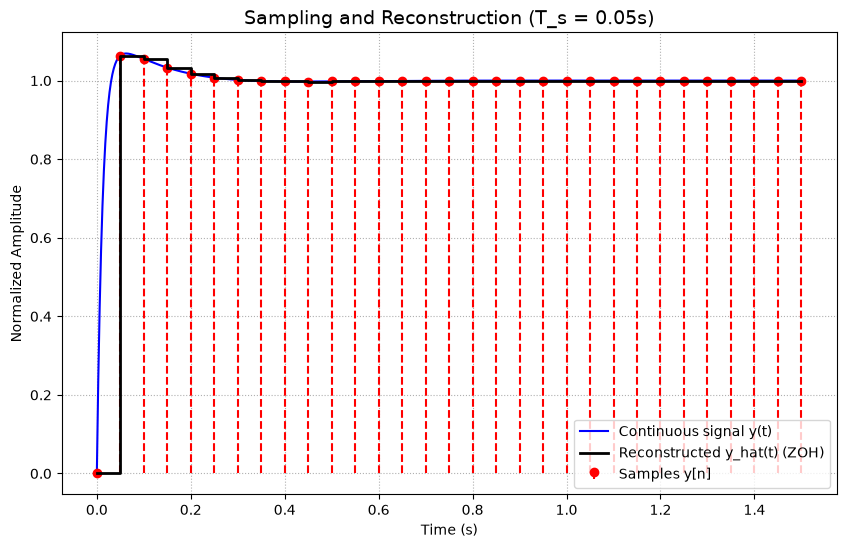

In [ ]:
# --- SAMPLING AND RECONSTRUCTION (ZOH) ---
# (images saved only when SAVE_IMAGES=True)

sys_PID = systems["PID"]

# Continuous signal
t_cont = np.linspace(0, 1.5, 1000)
_, y_cont = ct.step_response(sys_PID, T=t_cont)

# Sampling
T_s = 0.05
t_samp = np.arange(0, 1.5 + T_s, T_s)
_, y_samp = ct.step_response(sys_PID, T=t_samp)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(t_cont, y_cont, 'b-', linewidth=1.5, label='Continuous signal y(t)')
plt.stem(t_samp, y_samp, linefmt='r--', markerfmt='ro', basefmt=' ', label='Samples y[n]')
plt.step(t_samp, y_samp, where='post', color='k', linewidth=2, label='Reconstructed y_hat(t) (ZOH)')
plt.title(f'Sampling and Reconstruction (T_s = {T_s}s)', fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('Normalized Amplitude')
plt.grid(True, linestyle=':')
plt.legend(loc='lower right')
savefig_cond('images/zoh_reconstruction.png', dpi=150)
plt.show()


# Step 11: Lathi Section 5.7 — Digital Processing of Analog Signals

Following Lathi Section 5.7, to digitize an analog system $H_a(s)$ we can design a discrete filter $H[z]$ by impulse invariance. The discrete impulse response samples the continuous impulse response scaled by $T$:

$$h[n] = T \cdot h_a(nT)$$

Limitation (Aliasing): continuous systems rarely have strictly limited bandwidth, so frequency components above Nyquist ($\pi/T$) fold back into the baseband.

We reproduce Example 5.16: discrete design of a 1st-order Butterworth low-pass filter:

$$H_a(s) = \frac{\omega_c}{s + \omega_c}, \quad \omega_c = 10^5 \text{ rad/s}$$

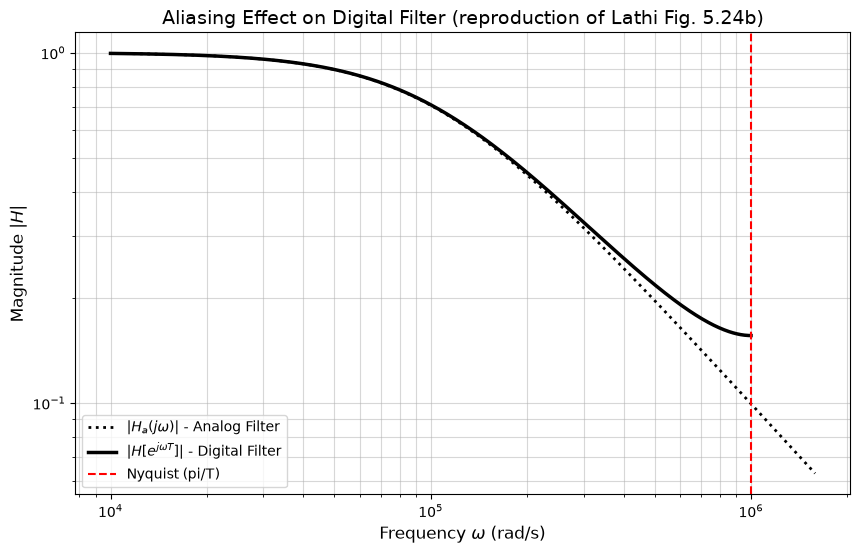

In [ ]:
# --- LATHI SECTION 5.7 SIMULATION (EXAMPLE 5.16) ---
import os

wc = 10**5
Ha_s = ct.tf([wc], [1, wc])

T = np.pi * 1e-6
w_nyquist = np.pi / T

Hz = ct.sample_system(Ha_s, T, method='impulse')

w = np.logspace(4, 6.2, 500)
resp_a = ct.frequency_response(Ha_s, omega=w)
mag_a = resp_a.magnitude

w_d = np.logspace(4, np.log10(w_nyquist), 500)
resp_d = ct.frequency_response(Hz, omega=w_d)
mag_d = resp_d.magnitude

K = 0.858

plt.figure(figsize=(10, 6))
plt.loglog(w, mag_a, 'k:', linewidth=2, label=r'$|H_a(j\\omega)|$ - Analog Filter')
plt.loglog(w_d, mag_d * K, 'k-', linewidth=2.5, label=r'$|H[e^{j\\omega T}]|$ - Digital Filter')
plt.axvline(w_nyquist, color='r', linestyle='--', label='Nyquist (pi/T)')
plt.title('Aliasing Effect on Digital Filter (reproduction of Lathi Fig. 5.24b)', fontsize=14)
plt.xlabel(r'Frequency $\\omega$ (rad/s)', fontsize=12)
plt.ylabel('Magnitude $|H|$', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
savefig_cond('images/lathi_aliasing.png', dpi=150)
plt.show()


Conceptual explanation for the report: the continuous curve shows the original analog filter and the digital curve shows the sampled/invariant-impulse version. Aliasing causes the digital curve to deviate above Nyquist, as expected from theory.

# Final Remarks and Recommendations

- The notebook models a DC motor driving a nonlinear aerodynamic load (fan) and linearizes the model around an operating point to apply classical control design techniques.
- Results: In open-loop the plant behaves nearly critically damped (very small overshoot). The designed PID (pole placement) meets the specified transient targets in most scenarios shown in the notebook.
- Notes for repository best practices:
  - Dependencies have been moved to a `requirements.txt` file so users can install the exact libraries with `pip install -r requirements.txt`.
  - Installation commands that run automatically inside the notebook were removed — dependency management should be explicit and handled outside the notebook.
  - Consider saving key plots to `images/` and moving reusable code to `src/` as a module for reproducibility and testing.

If you want, I can (1) rename remaining Portuguese labels/strings, (2) save important figures to an `images/` folder, and (3) extract simulation functions into `src/motor_simulation.py`.
